# Fusion Analysis

## 1 Overview

## 2 Importing Libraries

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ai.multimodal_pipeline import MultimodalPipeline

print("Project root:", PROJECT_ROOT)

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project


## 3 Controlled Evaluation Clips

In [3]:
CLIP_FOLDER = PROJECT_ROOT / "data" / "raw" / "fusion_clips"

clips = sorted(CLIP_FOLDER.glob("*.mp4"))

print("Folder:", CLIP_FOLDER)
print("Number of clips:", len(clips))

for clip in clips:
    print(clip.name)

Folder: c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\data\raw\fusion_clips
Number of clips: 15
clip01.mp4
clip02.mp4
clip03.mp4
clip04.mp4
clip05.mp4
clip06.mp4
clip07.mp4
clip08.mp4
clip09.mp4
clip10.mp4
clip11.mp4
clip12.mp4
clip13.mp4
clip14.mp4
clip15.mp4


## 4 Expected Scenario Labels

In [4]:
expected_labels = {
    "clip01": "High",
    "clip02": "High",
    "clip03": "High",

    "clip04": "Low",
    "clip05": "Low",
    "clip06": "Low",

    "clip07": "High",
    "clip08": "High",
    "clip09": "High",

    "clip10": "Mixed",
    "clip11": "Mixed",
    "clip12": "Mixed",

    "clip13": "Mixed",
    "clip14": "Mixed",
    "clip15": "Mixed",
}

expected_df = pd.DataFrame(
    expected_labels.items(),
    columns=["Clip", "Expected"]
)

expected_df

,Clip,Expected
0,clip01,High
1,clip02,High
2,clip03,High
3,clip04,Low
4,clip05,Low
5,clip06,Low
6,clip07,High
7,clip08,High
8,clip09,High
9,clip10,Mixed


## 5 Loading the Solace Pipeline

In [5]:
pipeline = MultimodalPipeline()

print("Solace multimodal pipeline loaded.")

Solace multimodal pipeline loaded.


## 6 Running the Evaluation Clips

In [6]:
rows = []

for clip in clips:

    print(f"Processing {clip.name}...")

    temporary_audio = None

    try:
        # Extract audio from video
        temporary_audio = pipeline.extract_audio(str(clip))
        audio_path = temporary_audio

        # Whisper transcript
        transcript = pipeline.transcribe(
            audio_path,
            "English"
        )

        # Three primary model scores
        text_score = pipeline.text_score(transcript)
        audio_score = pipeline.audio_score(audio_path)
        vision_score = pipeline.vision_score(str(clip))

        # Five supporting signals
        visual = pipeline.visual_signals(str(clip))

        speech = pipeline.speech_signals(
            transcript,
            audio_path,
            "English"
        )

        supporting_scores = [
            speech["speech_signal"],
            speech["disfluency_signal"],
            speech["lexical_signal"],
            visual["blink_signal"],
            visual["head_signal"],
        ]

        primary_scores = [
            text_score,
            audio_score,
            vision_score
        ]

        # Actual Solace fusion
        (
            primary_strain,
            supporting_strain,
            full_strain,
            primary_weight
        ) = pipeline.fuse(
            primary_scores,
            supporting_scores
        )

        rows.append({
            "Clip": clip.stem,

            "Transcript": transcript,

            # Primary model strain scores
            "Text strain": text_score * 100,
            "Audio strain": audio_score * 100,
            "Vision strain": vision_score * 100,

            # Five supporting signals
            "Blink signal": visual["blink_signal"] * 100,
            "Head signal": visual["head_signal"] * 100,
            "Speech signal": speech["speech_signal"] * 100,
            "Disfluency signal": speech["disfluency_signal"] * 100,
            "Lexical signal": speech["lexical_signal"] * 100,

            # Fusion outputs
            "Pipeline primary strain": primary_strain * 100,
            "Full Solace strain": full_strain * 100,
            "Primary weight": primary_weight * 100,
        })

        print(f"Finished {clip.name}")

    finally:
        if temporary_audio:
            Path(temporary_audio).unlink(
                missing_ok=True
            )

Processing clip01.mp4...


Device set to use cuda:0
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Device set to use cuda:0
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


Finished clip01.mp4
Processing clip02.mp4...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Finished clip02.mp4
Processing clip03.mp4...
Finished clip03.mp4
Processing clip04.mp4...
Finished clip04.mp4
Processing clip05.mp4...
Finished clip05.mp4
Processing clip06.mp4...
Finished clip06.mp4
Processing clip07.mp4...
Finished clip07.mp4
Processing clip08.mp4...
Finished clip08.mp4
Processing clip09.mp4...
Finished clip09.mp4
Processing clip10.mp4...
Finished clip10.mp4
Processing clip11.mp4...
Finished clip11.mp4
Processing clip12.mp4...
Finished clip12.mp4
Processing clip13.mp4...
Finished clip13.mp4
Processing clip14.mp4...
Finished clip14.mp4
Processing clip15.mp4...
Finished clip15.mp4


In [7]:
results_df = pd.DataFrame(rows)

print("Processed clips:", len(results_df))
results_df.head()

Processed clips: 15


,Clip,Transcript,Text strain,Audio strain,Vision strain,Blink signal,Head signal,Speech signal,Disfluency signal,Lexical signal,Pipeline primary strain,Full Solace strain,Primary weight
0,clip01,"This week, I'm really looking forward to catch...",1.159112,12.125005,19.605092,0.000000,0.0,0.724194,0.0,0.0,12.125005,10.926988,90.0
1,clip02,Something that made me really happy recently w...,0.385351,10.227817,9.574668,0.000000,0.0,0.000000,0.0,0.0,9.574668,8.617202,90.0
2,clip03,I absolutely love spending my free time being ...,0.708807,9.488600,14.480449,0.000000,0.0,0.000000,0.0,0.0,9.488600,8.539740,90.0
3,clip04,Today was such a long and exhausting day. From...,94.014553,50.691248,22.889479,0.000000,0.0,0.000000,0.0,0.0,50.691248,45.622123,90.0
4,clip05,There's been something on my mind lately that ...,95.845613,67.530455,11.347390,51.812686,0.0,0.000000,0.0,0.0,67.530455,61.813663,90.0


## 7 Individual Modality Results

In [8]:
results_df["Text only"] = (
    100 - results_df["Text strain"]
)

results_df["Audio only"] = (
    100 - results_df["Audio strain"]
)

results_df["Vision only"] = (
    100 - results_df["Vision strain"]
)

results_df[
    [
        "Clip",
        "Text only",
        "Audio only",
        "Vision only"
    ]
].round(2)

,Clip,Text only,Audio only,Vision only
0,clip01,98.84,87.87,80.39
1,clip02,99.61,89.77,90.43
2,clip03,99.29,90.51,85.52
3,clip04,5.99,49.31,77.11
4,clip05,4.15,32.47,88.65
5,clip06,9.04,14.57,83.76
6,clip07,97.84,90.96,87.09
7,clip08,97.79,87.71,90.75
8,clip09,94.61,89.66,84.82
9,clip10,98.52,85.62,79.02


## 8 Equal Three Model Fusion

In [9]:
results_df["Equal fusion wellbeing"] = 100 - (
    (
        results_df["Text strain"]
        + results_df["Audio strain"]
        + results_df["Vision strain"]
    ) / 3
)

results_df[
    [
        "Clip",
        "Text only",
        "Audio only",
        "Vision only",
        "Equal fusion wellbeing"
    ]
].round(2)

,Clip,Text only,Audio only,Vision only,Equal fusion wellbeing
0,clip01,98.84,87.87,80.39,89.04
1,clip02,99.61,89.77,90.43,93.27
2,clip03,99.29,90.51,85.52,91.77
3,clip04,5.99,49.31,77.11,44.13
4,clip05,4.15,32.47,88.65,41.76
5,clip06,9.04,14.57,83.76,35.79
6,clip07,97.84,90.96,87.09,91.96
7,clip08,97.79,87.71,90.75,92.09
8,clip09,94.61,89.66,84.82,89.70
9,clip10,98.52,85.62,79.02,87.72


## 9 Full Solace Fusion

In [10]:
results_df["Full Solace fusion"] = (
    100 - results_df["Full Solace strain"]
)

results_df[
    [
        "Clip",
        "Text only",
        "Audio only",
        "Vision only",
        "Equal fusion wellbeing",
        "Full Solace fusion"
    ]
].round(2)

,Clip,Text only,Audio only,Vision only,Equal fusion wellbeing,Full Solace fusion
0,clip01,98.84,87.87,80.39,89.04,89.07
1,clip02,99.61,89.77,90.43,93.27,91.38
2,clip03,99.29,90.51,85.52,91.77,91.46
3,clip04,5.99,49.31,77.11,44.13,54.38
4,clip05,4.15,32.47,88.65,41.76,38.19
5,clip06,9.04,14.57,83.76,35.79,22.73
6,clip07,97.84,90.96,87.09,91.96,91.86
7,clip08,97.79,87.71,90.75,92.09,90.32
8,clip09,94.61,89.66,84.82,89.70,90.70
9,clip10,98.52,85.62,79.02,87.72,87.06


In [11]:
print(
    "Primary weights found:",
    results_df["Primary weight"].unique()
)

Primary weights found: [90.]


## 10 Convert Scores to Wellbeing Bands

In [12]:
def wellbeing_band(score):
    if score >= 67:
        return "High"
    elif score >= 34:
        return "Mixed"
    else:
        return "Low"

In [13]:
results_df["Expected"] = (
    results_df["Clip"].map(expected_labels)
)

results_df[
    ["Clip", "Expected"]
]

,Clip,Expected
0,clip01,High
1,clip02,High
2,clip03,High
3,clip04,Low
4,clip05,Low
5,clip06,Low
6,clip07,High
7,clip08,High
8,clip09,High
9,clip10,Mixed


In [14]:
configurations = {
    "Text only": "Text only",
    "Audio only": "Audio only",
    "Vision only": "Vision only",
    "Equal fusion": "Equal fusion wellbeing",
    "Full Solace fusion": "Full Solace fusion",
}

for name, column in configurations.items():
    results_df[f"{name} prediction"] = (
        results_df[column].apply(wellbeing_band)
    )

In [15]:
prediction_columns = [
    "Clip",
    "Expected",
    "Text only prediction",
    "Audio only prediction",
    "Vision only prediction",
    "Equal fusion prediction",
    "Full Solace fusion prediction",
]

results_df[prediction_columns]

,Clip,Expected,Text only prediction,Audio only prediction,Vision only prediction,Equal fusion prediction,Full Solace fusion prediction
0,clip01,High,High,High,High,High,High
1,clip02,High,High,High,High,High,High
2,clip03,High,High,High,High,High,High
3,clip04,Low,Low,Mixed,High,Mixed,Mixed
4,clip05,Low,Low,Low,High,Mixed,Mixed
5,clip06,Low,Low,Low,High,Mixed,Low
6,clip07,High,High,High,High,High,High
7,clip08,High,High,High,High,High,High
8,clip09,High,High,High,High,High,High
9,clip10,Mixed,High,High,High,High,High


## 11 Accuracy and Macro-F1 Comparison

In [16]:
evaluation_rows = []

y_true = results_df["Expected"]

for name in configurations:

    y_pred = results_df[
        f"{name} prediction"
    ]

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=["Low", "Mixed", "High"],
        average="macro",
        zero_division=0
    )

    evaluation_rows.append({
        "Configuration": name,
        "Accuracy": accuracy,
        "Macro-F1": macro_f1
    })

evaluation_df = pd.DataFrame(
    evaluation_rows
)

evaluation_df[
    ["Accuracy", "Macro-F1"]
] = evaluation_df[
    ["Accuracy", "Macro-F1"]
].round(3)

evaluation_df

,Configuration,Accuracy,Macro-F1
0,Text only,0.667,0.631
1,Audio only,0.600,0.540
2,Vision only,0.400,0.190
3,Equal fusion,0.533,0.371
4,Full Solace fusion,0.600,0.550


In [17]:
display_df = evaluation_df.copy()

display_df["Accuracy"] = (
    display_df["Accuracy"] * 100
).round(1)

display_df["Macro-F1"] = (
    display_df["Macro-F1"] * 100
).round(1)

display_df.columns = [
    "Configuration",
    "Accuracy (%)",
    "Macro-F1 (%)"
]

display_df

,Configuration,Accuracy (%),Macro-F1 (%)
0,Text only,66.7,63.1
1,Audio only,60.0,54.0
2,Vision only,40.0,19.0
3,Equal fusion,53.3,37.1
4,Full Solace fusion,60.0,55.0


## 12 Ranking of Fusion Configurations

In [18]:
ranking_df = evaluation_df.sort_values(
    by=["Macro-F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

ranking_df.index = ranking_df.index + 1

ranking_df

,Configuration,Accuracy,Macro-F1
1,Text only,0.667,0.631
2,Full Solace fusion,0.600,0.550
3,Audio only,0.600,0.540
4,Equal fusion,0.533,0.371
5,Vision only,0.400,0.190


In [19]:
best_configuration = ranking_df.iloc[0]

print(
    "Best configuration:",
    best_configuration["Configuration"]
)

print(
    "Macro-F1:",
    round(
        best_configuration["Macro-F1"],
        3
    )
)

print(
    "Accuracy:",
    round(
        best_configuration["Accuracy"],
        3
    )
)

Best configuration: Text only
Macro-F1: 0.631
Accuracy: 0.667


## 13 Performance Comparison

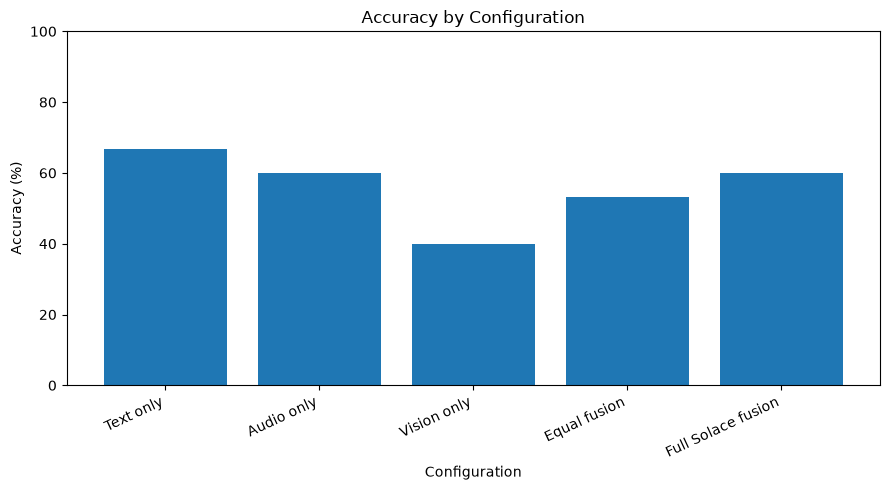

In [20]:
plt.figure(figsize=(9, 5))

plt.bar(
    display_df["Configuration"],
    display_df["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Configuration")
plt.title("Accuracy by Configuration")
plt.ylim(0, 100)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

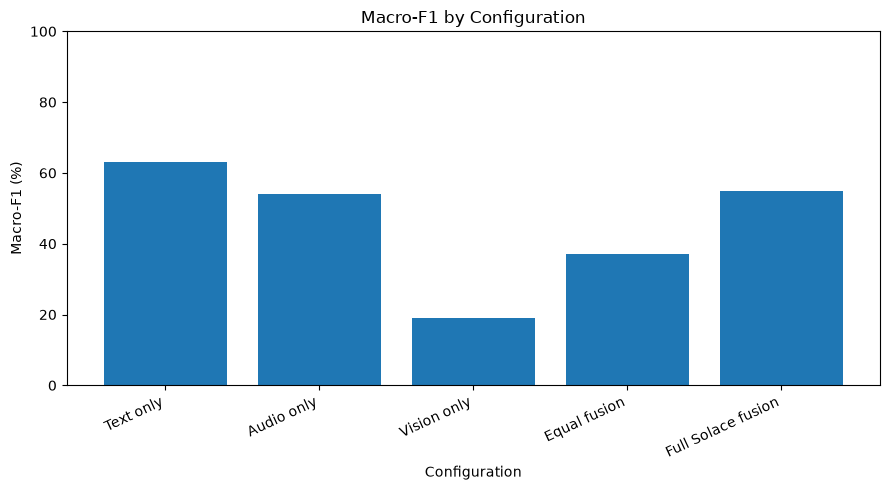

In [21]:
plt.figure(figsize=(9, 5))

plt.bar(
    display_df["Configuration"],
    display_df["Macro-F1 (%)"]
)

plt.ylabel("Macro-F1 (%)")
plt.xlabel("Configuration")
plt.title("Macro-F1 by Configuration")
plt.ylim(0, 100)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 14 Error Analysis

In [22]:
error_columns = [
    "Clip",
    "Expected",
    "Text only prediction",
    "Audio only prediction",
    "Vision only prediction",
    "Equal fusion prediction",
    "Full Solace fusion prediction",
]

error_df = results_df[
    error_columns
].copy()

error_df["Full fusion correct"] = (
    error_df["Full Solace fusion prediction"]
    == error_df["Expected"]
)

error_df

,Clip,Expected,Text only prediction,Audio only prediction,Vision only prediction,Equal fusion prediction,Full Solace fusion prediction,Full fusion correct
0,clip01,High,High,High,High,High,High,True
1,clip02,High,High,High,High,High,High,True
2,clip03,High,High,High,High,High,High,True
3,clip04,Low,Low,Mixed,High,Mixed,Mixed,False
4,clip05,Low,Low,Low,High,Mixed,Mixed,False
5,clip06,Low,Low,Low,High,Mixed,Low,True
6,clip07,High,High,High,High,High,High,True
7,clip08,High,High,High,High,High,High,True
8,clip09,High,High,High,High,High,High,True
9,clip10,Mixed,High,High,High,High,High,False


In [23]:
full_fusion_errors = error_df[
    error_df["Full fusion correct"] == False
]

full_fusion_errors

,Clip,Expected,Text only prediction,Audio only prediction,Vision only prediction,Equal fusion prediction,Full Solace fusion prediction,Full fusion correct
3,clip04,Low,Low,Mixed,High,Mixed,Mixed,False
4,clip05,Low,Low,Low,High,Mixed,Mixed,False
9,clip10,Mixed,High,High,High,High,High,False
10,clip11,Mixed,High,High,High,High,High,False
13,clip14,Mixed,High,High,High,High,High,False
14,clip15,Mixed,High,Mixed,High,High,High,False


## 15 Conflicing Modality Amalysis

In [24]:
conflict_clips = [
    "clip10",
    "clip11",
    "clip12"
]

conflict_df = results_df[
    results_df["Clip"].isin(
        conflict_clips
    )
][
    [
        "Clip",
        "Expected",
        "Text only",
        "Audio only",
        "Vision only",
        "Equal fusion wellbeing",
        "Full Solace fusion",
        "Text only prediction",
        "Audio only prediction",
        "Vision only prediction",
        "Equal fusion prediction",
        "Full Solace fusion prediction",
    ]
]

conflict_df.round(2)

,Clip,Expected,Text only,Audio only,Vision only,Equal fusion wellbeing,Full Solace fusion,Text only prediction,Audio only prediction,Vision only prediction,Equal fusion prediction,Full Solace fusion prediction
9,clip10,Mixed,98.52,85.62,79.02,87.72,87.06,High,High,High,High,High
10,clip11,Mixed,98.06,80.97,81.93,86.99,83.69,High,High,High,High,High
11,clip12,Mixed,6.69,27.10,90.29,41.36,34.39,Low,Low,High,Mixed,Mixed


In [25]:
for name in configurations:

    correct = (
        conflict_df[
            f"{name} prediction"
        ]
        == conflict_df["Expected"]
    ).sum()

    print(
        f"{name}: "
        f"{correct}/{len(conflict_df)} correct"
    )

Text only: 0/3 correct
Audio only: 0/3 correct
Vision only: 0/3 correct
Equal fusion: 1/3 correct
Full Solace fusion: 1/3 correct


## 16 Supporting-Signal Analysis

In [26]:
support_columns = [
    "Clip",
    "Blink signal",
    "Head signal",
    "Speech signal",
    "Disfluency signal",
    "Lexical signal",
]

results_df[
    support_columns
].round(2)

,Clip,Blink signal,Head signal,Speech signal,Disfluency signal,Lexical signal
0,clip01,0.00,0.0,0.72,0.0,0.0
1,clip02,0.00,0.0,0.00,0.0,0.0
2,clip03,0.00,0.0,0.00,0.0,0.0
3,clip04,0.00,0.0,0.00,0.0,0.0
4,clip05,51.81,0.0,0.00,0.0,0.0
5,clip06,19.20,0.0,0.00,0.0,0.0
6,clip07,0.00,0.0,0.00,0.0,0.0
7,clip08,68.03,0.0,0.00,0.0,0.0
8,clip09,0.00,0.0,0.00,0.0,0.0
9,clip10,0.00,0.0,0.00,0.0,0.0


In [27]:
results_df[
    "Supporting contribution"
] = (
    results_df["Blink signal"] * 0.02
    + results_df["Head signal"] * 0.02
    + results_df["Speech signal"] * 0.02
    + results_df["Disfluency signal"] * 0.02
    + results_df["Lexical signal"] * 0.02
)

In [28]:
results_df[
    "Primary contribution"
] = (
    results_df["Pipeline primary strain"]
    * results_df["Primary weight"]
    / 100
)

In [29]:
results_df[
    "Reconstructed Solace strain"
] = (
    results_df["Primary contribution"]
    + results_df["Supporting contribution"]
)

results_df[
    [
        "Clip",
        "Primary contribution",
        "Supporting contribution",
        "Reconstructed Solace strain",
        "Full Solace strain"
    ]
].round(3)

,Clip,Primary contribution,Supporting contribution,Reconstructed Solace strain,Full Solace strain
0,clip01,10.913,0.014,10.927,10.927
1,clip02,8.617,0.000,8.617,8.617
2,clip03,8.540,0.000,8.540,8.540
3,clip04,45.622,0.000,45.622,45.622
4,clip05,60.777,1.036,61.814,61.814
5,clip06,76.887,0.384,77.271,77.271
6,clip07,8.139,0.000,8.139,8.139
7,clip08,8.322,1.361,9.682,9.682
8,clip09,9.302,0.000,9.302,9.302
9,clip10,12.942,0.000,12.942,12.942


In [30]:
difference = (
    results_df["Reconstructed Solace strain"]
    - results_df["Full Solace strain"]
).abs()

print(
    "Maximum difference:",
    difference.max()
)

Maximum difference: 1.4210854715202004e-14


## 17 Fusion Method Investigation

### 17.1 Reliability-Based Weights

In [31]:
TEXT_F1 = 0.7321
AUDIO_F1 = 0.6594
VISION_F1 = 0.5813

total_f1 = (
    TEXT_F1
    + AUDIO_F1
    + VISION_F1
)

text_weight = TEXT_F1 / total_f1
audio_weight = AUDIO_F1 / total_f1
vision_weight = VISION_F1 / total_f1

print(
    f"Text weight:   {text_weight:.3f}"
)

print(
    f"Audio weight:  {audio_weight:.3f}"
)

print(
    f"Vision weight: {vision_weight:.3f}"
)

print(
    "Total:",
    round(
        text_weight
        + audio_weight
        + vision_weight,
        3
    )
)

Text weight:   0.371
Audio weight:  0.334
Vision weight: 0.295
Total: 1.0


### 17.2 Reliabilty-Weighted Primary Fusion

In [32]:
results_df[
    "Reliability primary strain"
] = (
    results_df["Text strain"]
    * text_weight

    + results_df["Audio strain"]
    * audio_weight

    + results_df["Vision strain"]
    * vision_weight
)

In [33]:
results_df[
    "Reliability fusion wellbeing"
] = (
    100
    - results_df[
        "Reliability primary strain"
    ]
)

### 17.3 Reability Fusion + Five Supporting Signals

In [34]:
results_df[
    "Reliability full strain"
] = (
    results_df["Reliability primary strain"]
    * results_df["Primary weight"]
    / 100
    + results_df["Supporting contribution"]
)

In [35]:
results_df[
    "Reliability full wellbeing"
] = (
    100
    - results_df[
        "Reliability full strain"
    ]
)

### 17.4 Median Fusion

In [36]:
results_df[
    "Median primary strain"
] = results_df[
    [
        "Text strain",
        "Audio strain",
        "Vision strain"
    ]
].median(axis=1)

In [37]:
results_df[
    "Median fusion wellbeing"
] = (
    100
    - results_df[
        "Median primary strain"
    ]
)

In [38]:
results_df[
    "Median full strain"
] = (
    results_df["Median primary strain"]
    * results_df["Primary weight"]
    / 100
    + results_df["Supporting contribution"]
)

In [39]:
results_df[
    "Median full wellbeing"
] = (
    100
    - results_df[
        "Median full strain"
    ]
)

## 18 Compare Fusion Strategies

In [40]:
new_methods = {
    "Equal fusion":
        "Equal fusion wellbeing",

    "Original Full Solace":
        "Full Solace fusion",

    "Reliability primary":
        "Reliability fusion wellbeing",

    "Reliability + supports":
        "Reliability full wellbeing",

    "Median primary":
        "Median fusion wellbeing",

    "Median + supports":
        "Median full wellbeing",
}

for name, column in new_methods.items():

    results_df[
        f"{name} prediction"
    ] = results_df[
        column
    ].apply(
        wellbeing_band
    )

In [41]:
fusion_evaluation = []

y_true = results_df["Expected"]

for name in new_methods:

    y_pred = results_df[
        f"{name} prediction"
    ]

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=[
            "Low",
            "Mixed",
            "High"
        ],
        average="macro",
        zero_division=0
    )

    fusion_evaluation.append({
        "Fusion method": name,
        "Accuracy": accuracy,
        "Macro-F1": macro_f1
    })

fusion_evaluation_df = pd.DataFrame(
    fusion_evaluation
)

fusion_evaluation_df[
    ["Accuracy", "Macro-F1"]
] = fusion_evaluation_df[
    ["Accuracy", "Macro-F1"]
].round(3)

fusion_evaluation_df

,Fusion method,Accuracy,Macro-F1
0,Equal fusion,0.533,0.371
1,Original Full Solace,0.600,0.550
2,Reliability primary,0.600,0.550
3,Reliability + supports,0.533,0.371
4,Median primary,0.600,0.556
5,Median + supports,0.600,0.550


In [42]:
fusion_ranking_df = (
    fusion_evaluation_df
    .sort_values(
        by=[
            "Macro-F1",
            "Accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

fusion_ranking_df.index += 1

fusion_ranking_df

,Fusion method,Accuracy,Macro-F1
1,Median primary,0.600,0.556
2,Original Full Solace,0.600,0.550
3,Reliability primary,0.600,0.550
4,Median + supports,0.600,0.550
5,Equal fusion,0.533,0.371
6,Reliability + supports,0.533,0.371


### 18.1 Include Individual Models

In [43]:
final_comparison_methods = {
    "Text only":
        "Text only",

    "Audio only":
        "Audio only",

    "Vision only":
        "Vision only",

    "Equal fusion":
        "Equal fusion wellbeing",

    "Original Full Solace":
        "Full Solace fusion",

    "Reliability + supports":
        "Reliability full wellbeing",

    "Median + supports":
        "Median full wellbeing",
}

In [44]:
final_rows = []

for name, column in final_comparison_methods.items():

    predictions = (
        results_df[column]
        .apply(wellbeing_band)
    )

    final_rows.append({
        "Configuration": name,

        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Macro-F1": f1_score(
            y_true,
            predictions,
            labels=[
                "Low",
                "Mixed",
                "High"
            ],
            average="macro",
            zero_division=0
        )
    })

final_comparison_df = pd.DataFrame(
    final_rows
)

final_comparison_df[
    ["Accuracy", "Macro-F1"]
] = final_comparison_df[
    ["Accuracy", "Macro-F1"]
].round(3)

final_comparison_df.sort_values(
    "Macro-F1",
    ascending=False
)

,Configuration,Accuracy,Macro-F1
0,Text only,0.667,0.631
4,Original Full Solace,0.600,0.550
6,Median + supports,0.600,0.550
1,Audio only,0.600,0.540
3,Equal fusion,0.533,0.371
5,Reliability + supports,0.533,0.371
2,Vision only,0.400,0.190


In [45]:
selected_fusion_method = "Original Full Solace"

selected_fusion_column = (
    new_methods[
        selected_fusion_method
    ]
)

print(
    "Frozen fusion method:",
    selected_fusion_method
)

print(
    "Fusion output column:",
    selected_fusion_column
)

Frozen fusion method: Original Full Solace
Fusion output column: Full Solace fusion


## 19 Additive Supporting-Signal Fusion

In [46]:
results_df[
    [
        "Clip",
        "Blink signal",
        "Head signal",
        "Speech signal",
        "Disfluency signal",
        "Lexical signal",
        "Supporting contribution"
    ]
].round(2)

,Clip,Blink signal,Head signal,Speech signal,Disfluency signal,Lexical signal,Supporting contribution
0,clip01,0.00,0.0,0.72,0.0,0.0,0.01
1,clip02,0.00,0.0,0.00,0.0,0.0,0.00
2,clip03,0.00,0.0,0.00,0.0,0.0,0.00
3,clip04,0.00,0.0,0.00,0.0,0.0,0.00
4,clip05,51.81,0.0,0.00,0.0,0.0,1.04
5,clip06,19.20,0.0,0.00,0.0,0.0,0.38
6,clip07,0.00,0.0,0.00,0.0,0.0,0.00
7,clip08,68.03,0.0,0.00,0.0,0.0,1.36
8,clip09,0.00,0.0,0.00,0.0,0.0,0.00
9,clip10,0.00,0.0,0.00,0.0,0.0,0.00


### 19.2 Equal Fusion + Additive Supports

In [47]:
results_df["Additive equal strain"] = np.clip(
    results_df["Pipeline primary strain"]
    + results_df["Supporting contribution"],
    0,
    100
)

results_df["Additive equal wellbeing"] = (
    100 - results_df["Additive equal strain"]
)

In [48]:
results_df[
    [
        "Clip",
        "Pipeline primary strain",
        "Supporting contribution",
        "Additive equal strain",
        "Additive equal wellbeing"
    ]
].round(2)

,Clip,Pipeline primary strain,Supporting contribution,Additive equal strain,Additive equal wellbeing
0,clip01,12.13,0.01,12.14,87.86
1,clip02,9.57,0.00,9.57,90.43
2,clip03,9.49,0.00,9.49,90.51
3,clip04,50.69,0.00,50.69,49.31
4,clip05,67.53,1.04,68.57,31.43
5,clip06,85.43,0.38,85.81,14.19
6,clip07,9.04,0.00,9.04,90.96
7,clip08,9.25,1.36,10.61,89.39
8,clip09,10.34,0.00,10.34,89.66
9,clip10,14.38,0.00,14.38,85.62


### 19.3 Reliability Fusion + Additive Supports

In [49]:
results_df["Additive reliability strain"] = np.clip(
    results_df["Reliability primary strain"]
    + results_df["Supporting contribution"],
    0,
    100
)

results_df["Additive reliability wellbeing"] = (
    100 - results_df["Additive reliability strain"]
)

In [50]:
results_df[
    [
        "Clip",
        "Reliability primary strain",
        "Supporting contribution",
        "Additive reliability strain",
        "Additive reliability wellbeing"
    ]
].round(2)

,Clip,Reliability primary strain,Supporting contribution,Additive reliability strain,Additive reliability wellbeing
0,clip01,10.26,0.01,10.27,89.73
1,clip02,6.38,0.00,6.38,93.62
2,clip03,7.70,0.00,7.70,92.30
3,clip04,58.58,0.00,58.58,41.42
4,clip05,61.48,1.04,62.52,37.48
5,clip06,67.09,0.38,67.48,32.52
6,clip07,7.63,0.00,7.63,92.37
7,clip08,7.65,1.36,9.01,90.99
8,clip09,9.93,0.00,9.93,90.07
9,clip10,11.54,0.00,11.54,88.46


## 20 Evaluation of Additive Supporting Signals

In [51]:
results_df["Additive equal prediction"] = (
    results_df["Additive equal wellbeing"]
    .apply(wellbeing_band)
)

results_df["Additive reliability prediction"] = (
    results_df["Additive reliability wellbeing"]
    .apply(wellbeing_band)
)

In [52]:
methods_to_compare = {
    "Text only": "Text only",
    "Audio only": "Audio only",
    "Vision only": "Vision only",
    
    "Equal primary": "Equal fusion wellbeing",
    "Original Full Solace": "Full Solace fusion",
    
    "Reliability primary": "Reliability fusion wellbeing",
    
    "Additive equal": "Additive equal wellbeing",
    "Additive reliability": "Additive reliability wellbeing",
}

In [53]:
comparison_rows = []

y_true = results_df["Expected"]

for name, column in methods_to_compare.items():

    y_pred = (
        results_df[column]
        .apply(wellbeing_band)
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=["Low", "Mixed", "High"],
        average="macro",
        zero_division=0
    )

    comparison_rows.append({
        "Configuration": name,
        "Accuracy": accuracy,
        "Macro-F1": macro_f1
    })

additive_comparison_df = pd.DataFrame(
    comparison_rows
)

additive_comparison_df[
    ["Accuracy", "Macro-F1"]
] = additive_comparison_df[
    ["Accuracy", "Macro-F1"]
].round(3)

additive_comparison_df

,Configuration,Accuracy,Macro-F1
0,Text only,0.667,0.631
1,Audio only,0.600,0.540
2,Vision only,0.400,0.190
3,Equal primary,0.533,0.371
4,Original Full Solace,0.600,0.550
5,Reliability primary,0.600,0.550
6,Additive equal,0.600,0.556
7,Additive reliability,0.600,0.550


In [54]:
additive_ranking_df = (
    additive_comparison_df
    .sort_values(
        ["Macro-F1", "Accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

additive_ranking_df.index += 1

additive_ranking_df

,Configuration,Accuracy,Macro-F1
1,Text only,0.667,0.631
2,Additive equal,0.600,0.556
3,Original Full Solace,0.600,0.550
4,Reliability primary,0.600,0.550
5,Additive reliability,0.600,0.550
6,Audio only,0.600,0.540
7,Equal primary,0.533,0.371
8,Vision only,0.400,0.190


In [55]:
support_effect_df = results_df[
    [
        "Clip",
        "Expected",
        "Supporting contribution",
        "Reliability fusion wellbeing",
        "Additive reliability wellbeing"
    ]
].copy()

support_effect_df[
    "Reliability prediction"
] = support_effect_df[
    "Reliability fusion wellbeing"
].apply(wellbeing_band)

support_effect_df[
    "Additive prediction"
] = support_effect_df[
    "Additive reliability wellbeing"
].apply(wellbeing_band)

support_effect_df.round(2)

,Clip,Expected,Supporting contribution,Reliability fusion wellbeing,Additive reliability wellbeing,Reliability prediction,Additive prediction
0,clip01,High,0.01,89.74,89.73,High,High
1,clip02,High,0.00,93.62,93.62,High,High
2,clip03,High,0.00,92.30,92.30,High,High
3,clip04,Low,0.00,41.42,41.42,Mixed,Mixed
4,clip05,Low,1.04,38.52,37.48,Mixed,Mixed
5,clip06,Low,0.38,32.91,32.52,Low,Low
6,clip07,High,0.00,92.37,92.37,High,High
7,clip08,High,1.36,92.35,90.99,High,High
8,clip09,High,0.00,90.07,90.07,High,High
9,clip10,Mixed,0.00,88.46,88.46,High,High


In [56]:
changed_predictions = support_effect_df[
    support_effect_df["Reliability prediction"]
    != support_effect_df["Additive prediction"]
]

changed_predictions

,Clip,Expected,Supporting contribution,Reliability fusion wellbeing,Additive reliability wellbeing,Reliability prediction,Additive prediction


## 21 Supporting Signal Functional Validation

In [57]:
support_test_rows = []

In [58]:
def test_support_clip(
    clip_path,
    transcript,
    name
):
    temporary_audio = pipeline.extract_audio(
        str(clip_path)
    )

    try:
        visual = pipeline.visual_signals(
            str(clip_path)
        )

        speech = pipeline.speech_signals(
            transcript,
            temporary_audio,
            "English"
        )

        support_test_rows.append({
            "Test": name,

            "Blink rate":
                visual["blink_rate"],

            "Blink signal":
                visual["blink_signal"] * 100,

            "Head position":
                visual["head_position"],

            "Head signal":
                visual["head_signal"] * 100,

            "Speech rate":
                speech["speech_rate"],

            "Speech signal":
                speech["speech_signal"] * 100,

            "Disfluency rate":
                speech["disfluency_rate"],

            "Disfluency signal":
                speech["disfluency_signal"] * 100,

            "Lexical variety":
                speech["lexical_variety"],

            "Lexical signal":
                speech["lexical_signal"] * 100,
        })

    finally:
        Path(
            temporary_audio
        ).unlink(
            missing_ok=True
        )

In [59]:
support_folder = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "support_tests"
)

In [60]:
tests = {
    "support01": (
        "Today has been fairly normal. I finished my usual tasks, "
        "took a short break, and had some time to relax. "
        "I feel reasonably comfortable and everything has been "
        "going as expected."
    ),

    "support02": (
        "Today has been fairly normal. I completed my usual tasks "
        "and spent some time organising my work. Nothing particularly "
        "stressful happened, and the rest of the day has been quite ordinary."
    ),

    "support03": (
        "I am speaking normally while looking directly at the camera. "
        "Today has been an ordinary day and I have completed the things "
        "that I planned to do. Everything feels fairly normal."
    ),

    "support04": (
        "Today has been a long day. I completed several tasks and then "
        "took a break. I am feeling a little tired and I would like "
        "some time to rest."
    ),

    "support05": (
        "Um today was uh quite tiring. Erm I had a lot to do and um "
        "I found it difficult to concentrate. Hmm I think uh I just "
        "need some time to rest erm and recover."
    ),

    "support06": (
        "Tired tired tired. Work work work. Tired work, tired work, "
        "tired work. I am tired. Work is tiring. Tired, tired, tired. "
        "Work, work, work. Tired after work."
    ),
}
support_test_rows = []

for name, transcript in tests.items():

    clip_path = (
        support_folder
        / f"{name}.mp4"
    )

    test_support_clip(
        clip_path,
        transcript,
        name
    )

In [61]:
support_validation_df = pd.DataFrame(
    support_test_rows
)

support_validation_df.round(2)

,Test,Blink rate,Blink signal,Head position,Head signal,Speech rate,Speech signal,Disfluency rate,Disfluency signal,Lexical variety,Lexical signal
0,support01,4.54,43.19,Centred,0.00,143.87,0.00,0.0,0.0,0.87,0.00
1,support02,0.00,100.00,Slightly off-centre,1.99,103.92,0.00,0.0,0.0,0.84,0.00
2,support03,0.00,100.00,Centred,0.00,200.43,5.49,0.0,0.0,0.90,0.00
3,support04,1.42,82.29,Centred,0.00,41.26,58.74,0.0,0.0,0.83,0.00
4,support05,16.47,0.00,Centred,0.00,83.14,16.86,0.2,100.0,0.74,0.00
5,support06,0.00,100.00,Centred,0.00,88.09,11.91,0.0,0.0,0.26,42.39


In [62]:
blink_control_path = (
    support_folder
    / "support01_blink_control.mp4"
)

head_test_path = (
    support_folder
    / "support02_head.mp4"
)

In [63]:
blink_control_transcript = (
    "Today has been a fairly normal day. I completed the tasks that I planned "
    "to do and took a few short breaks during the day. Nothing particularly "
    "stressful happened, and I have been able to work at a comfortable pace. "
    "I spent some time organising my work and finishing a few small things "
    "that were left to complete. After that, I had some time to relax and "
    "think about what I want to do tomorrow. At the moment I feel reasonably "
    "comfortable and calm. Overall, the day has been quite ordinary, and "
    "everything has gone more or less as expected."
)

head_test_transcript = (
    "Today has been a normal day. I completed my usual work, organised a few "
    "tasks, and took some time to rest. Nothing unusual happened, and overall "
    "I feel fairly comfortable and relaxed."
)

In [64]:
support_test_rows = []

In [65]:
test_support_clip(
    blink_control_path,
    blink_control_transcript,
    "blink_control"
)

test_support_clip(
    head_test_path,
    head_test_transcript,
    "head_test"
)

In [66]:
control_validation_df = pd.DataFrame(
    support_test_rows
)

control_validation_df.round(2)

,Test,Blink rate,Blink signal,Head position,Head signal,Speech rate,Speech signal,Disfluency rate,Disfluency signal,Lexical variety,Lexical signal
0,blink_control,14.26,0.0,Centred,0.00,180.06,0,0.0,0.0,0.64,0.0
1,head_test,0.00,100.0,Off-centre,58.72,166.05,0,0.0,0.0,0.88,0.0


In [67]:
control_validation_df[
    [
        "Test",
        "Blink rate",
        "Blink signal",
        "Head position",
        "Head signal"
    ]
].round(2)

,Test,Blink rate,Blink signal,Head position,Head signal
0,blink_control,14.26,0.0,Centred,0.00
1,head_test,0.00,100.0,Off-centre,58.72


## 22 Pairwise Fusion Ablation

### 22.1 Calculate pairwise wellbeing scores

In [68]:
results_df["Text + Audio"] = (
    results_df["Text only"]
    + results_df["Audio only"]
) / 2

results_df["Text + Vision"] = (
    results_df["Text only"]
    + results_df["Vision only"]
) / 2

results_df["Audio + Vision"] = (
    results_df["Audio only"]
    + results_df["Vision only"]
) / 2

In [69]:
results_df[
    [
        "Clip",
        "Expected",
        "Text only",
        "Audio only",
        "Vision only",
        "Text + Audio",
        "Text + Vision",
        "Audio + Vision"
    ]
].round(2)

,Clip,Expected,Text only,Audio only,Vision only,Text + Audio,Text + Vision,Audio + Vision
0,clip01,High,98.84,87.87,80.39,93.36,89.62,84.13
1,clip02,High,99.61,89.77,90.43,94.69,95.02,90.10
2,clip03,High,99.29,90.51,85.52,94.90,92.41,88.02
3,clip04,Low,5.99,49.31,77.11,27.65,41.55,63.21
4,clip05,Low,4.15,32.47,88.65,18.31,46.40,60.56
5,clip06,Low,9.04,14.57,83.76,11.81,46.40,49.17
6,clip07,High,97.84,90.96,87.09,94.40,92.46,89.02
7,clip08,High,97.79,87.71,90.75,92.75,94.27,89.23
8,clip09,High,94.61,89.66,84.82,92.14,89.72,87.24
9,clip10,Mixed,98.52,85.62,79.02,92.07,88.77,82.32


### 22.2 Convert pairwise scores to predictions

In [70]:
pairwise_methods = {
    "Text + Audio": "Text + Audio",
    "Text + Vision": "Text + Vision",
    "Audio + Vision": "Audio + Vision",
}

for name, column in pairwise_methods.items():
    results_df[
        f"{name} prediction"
    ] = results_df[
        column
    ].apply(wellbeing_band)

### 22.3 Evaluate pairwise performance

In [71]:
pairwise_rows = []

y_true = results_df["Expected"]

for name, column in pairwise_methods.items():

    y_pred = results_df[
        f"{name} prediction"
    ]

    pairwise_rows.append({
        "Configuration": name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Macro-F1": f1_score(
            y_true,
            y_pred,
            labels=["Low", "Mixed", "High"],
            average="macro",
            zero_division=0
        )
    })

pairwise_df = pd.DataFrame(
    pairwise_rows
)

pairwise_df[
    ["Accuracy", "Macro-F1"]
] = pairwise_df[
    ["Accuracy", "Macro-F1"]
].round(3)

pairwise_df

,Configuration,Accuracy,Macro-F1
0,Text + Audio,0.600,0.500
1,Text + Vision,0.467,0.302
2,Audio + Vision,0.600,0.433


## 23 Complete Ablation Comparison

In [72]:
all_methods = {
    "Text only":
        "Text only",

    "Audio only":
        "Audio only",

    "Vision only":
        "Vision only",

    "Text + Audio":
        "Text + Audio",

    "Text + Vision":
        "Text + Vision",

    "Audio + Vision":
        "Audio + Vision",

    "Equal 3-model fusion":
        "Equal fusion wellbeing",

    "Original Full Solace":
        "Full Solace fusion",

    "Reliability-weighted fusion":
        "Reliability fusion wellbeing",

    "Additive reliability fusion":
        "Additive reliability wellbeing",

    "Median fusion":
        "Median fusion wellbeing",

    "Median + additive supports":
        "Median additive wellbeing",
}

In [73]:
results_df["Median additive strain"] = np.clip(
    results_df["Median primary strain"]
    + results_df["Supporting contribution"],
    0,
    100
)

results_df["Median additive wellbeing"] = (
    100 - results_df["Median additive strain"]
)

In [74]:
results_df[
    [
        "Clip",
        "Median fusion wellbeing",
        "Supporting contribution",
        "Median additive wellbeing"
    ]
].round(2)

,Clip,Median fusion wellbeing,Supporting contribution,Median additive wellbeing
0,clip01,87.87,0.01,87.86
1,clip02,90.43,0.00,90.43
2,clip03,90.51,0.00,90.51
3,clip04,49.31,0.00,49.31
4,clip05,32.47,1.04,31.43
5,clip06,14.57,0.38,14.19
6,clip07,90.96,0.00,90.96
7,clip08,90.75,1.36,89.39
8,clip09,89.66,0.00,89.66
9,clip10,85.62,0.00,85.62


In [75]:
ablation_rows = []

for name, column in all_methods.items():

    predictions = (
        results_df[column]
        .apply(wellbeing_band)
    )

    ablation_rows.append({
        "Configuration": name,

        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Macro-F1": f1_score(
            y_true,
            predictions,
            labels=["Low", "Mixed", "High"],
            average="macro",
            zero_division=0
        )
    })

ablation_df = pd.DataFrame(
    ablation_rows
)

ablation_df[
    ["Accuracy", "Macro-F1"]
] = ablation_df[
    ["Accuracy", "Macro-F1"]
].round(3)

ablation_df = (
    ablation_df
    .sort_values(
        ["Macro-F1", "Accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

ablation_df.index += 1

ablation_df

,Configuration,Accuracy,Macro-F1
1,Text only,0.667,0.631
2,Median fusion,0.600,0.556
3,Median + additive supports,0.600,0.556
4,Original Full Solace,0.600,0.550
5,Reliability-weighted fusion,0.600,0.550
6,Additive reliability fusion,0.600,0.550
7,Audio only,0.600,0.540
8,Text + Audio,0.600,0.500
9,Audio + Vision,0.600,0.433
10,Equal 3-model fusion,0.533,0.371


In [76]:
ablation_display_df = ablation_df.copy()

ablation_display_df["Accuracy"] = (
    ablation_display_df["Accuracy"] * 100
).round(1)

ablation_display_df["Macro-F1"] = (
    ablation_display_df["Macro-F1"] * 100
).round(1)

ablation_display_df.columns = [
    "Configuration",
    "Accuracy (%)",
    "Macro-F1 (%)"
]

ablation_display_df

,Configuration,Accuracy (%),Macro-F1 (%)
1,Text only,66.7,63.1
2,Median fusion,60.0,55.6
3,Median + additive supports,60.0,55.6
4,Original Full Solace,60.0,55.0
5,Reliability-weighted fusion,60.0,55.0
6,Additive reliability fusion,60.0,55.0
7,Audio only,60.0,54.0
8,Text + Audio,60.0,50.0
9,Audio + Vision,60.0,43.3
10,Equal 3-model fusion,53.3,37.1


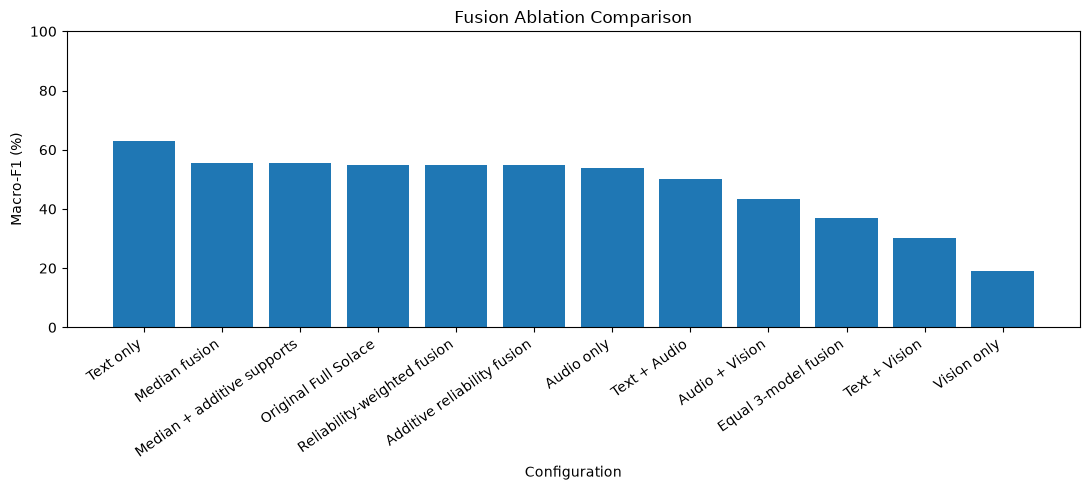

In [77]:
plt.figure(figsize=(11, 5))

plt.bar(
    ablation_display_df["Configuration"],
    ablation_display_df["Macro-F1 (%)"]
)

plt.ylabel("Macro-F1 (%)")
plt.xlabel("Configuration")
plt.title("Fusion Ablation Comparison")
plt.ylim(0, 100)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

## Held Out Evaluation

In [78]:
HOLDOUT_FOLDER = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "fusion_holdout"
)

holdout_manifest = pd.read_csv(
    HOLDOUT_FOLDER / "labels.csv"
)

assert {
    "Clip",
    "Expected"
}.issubset(
    holdout_manifest.columns
)

holdout_manifest.head()

,Clip,Expected
0,fusion_holdout01,Low
1,fusion_holdout02,Low
2,fusion_holdout03,Low
3,fusion_holdout04,Low
4,fusion_holdout05,Mixed


In [79]:
holdout_rows = []

for _, row in holdout_manifest.iterrows():

    clip_path = (
        HOLDOUT_FOLDER
        / f"{row['Clip']}.mp4"
    )

    temporary_audio = None

    try:

        temporary_audio = (
            pipeline.extract_audio(
                str(clip_path)
            )
        )

        transcript = pipeline.transcribe(
            temporary_audio,
            "English"
        )

        text_strain = pipeline.text_score(
            transcript
        )

        audio_strain = pipeline.audio_score(
            temporary_audio
        )

        vision_strain = pipeline.vision_score(
            str(clip_path)
        )

        # Supporting visual signals
        visual = pipeline.visual_signals(
            str(clip_path)
        )

        # Supporting speech signals
        speech = pipeline.speech_signals(
            transcript,
            temporary_audio,
            "English"
        )

        primary_scores = [
            text_strain,
            audio_strain,
            vision_strain
        ]

        supporting_scores = [
            speech["speech_signal"],
            speech["disfluency_signal"],
            speech["lexical_signal"],
            visual["blink_signal"],
            visual["head_signal"]
        ]

        (
            primary_strain,
            supporting_strain,
            full_strain,
            primary_weight,
        ) = pipeline.fuse(
            primary_scores,
            supporting_scores
        )

        full_wellbeing = 100 - (
            full_strain * 100
        )

        prediction = wellbeing_band(
            full_wellbeing
        )

        holdout_rows.append({
            "Clip": row["Clip"],
            "Expected": row["Expected"],

            "Text wellbeing":
                100 - text_strain * 100,

            "Audio wellbeing":
                100 - audio_strain * 100,

            "Vision wellbeing":
                100 - vision_strain * 100,

            "Primary wellbeing":
                100 - primary_strain * 100,

            "Primary weight":
                primary_weight * 100,

            "Full Solace wellbeing":
                full_wellbeing,

            "Prediction":
                prediction
        })

    finally:

        if temporary_audio:

            Path(
                temporary_audio
            ).unlink(
                missing_ok=True
            )

In [80]:
holdout_df = pd.DataFrame(
    holdout_rows
)

holdout_accuracy = accuracy_score(
    holdout_df["Expected"],
    holdout_df["Prediction"]
)

holdout_macro_f1 = f1_score(
    holdout_df["Expected"],
    holdout_df["Prediction"],
    labels=[
        "Low",
        "Mixed",
        "High"
    ],
    average="macro",
    zero_division=0
)

print(
    "Held-out fusion accuracy:",
    round(holdout_accuracy, 3)
)

print(
    "Held-out fusion Macro-F1:",
    round(holdout_macro_f1, 3)
)

holdout_df

Held-out fusion accuracy: 0.583
Held-out fusion Macro-F1: 0.508


,Clip,Expected,Text wellbeing,Audio wellbeing,Vision wellbeing,Primary wellbeing,Primary weight,Full Solace wellbeing,Prediction
0,fusion_holdout01,Low,5.754695,5.538976,95.882212,5.754695,90.0,14.774837,Low
1,fusion_holdout02,Low,8.256065,21.856471,93.997209,21.856471,90.0,28.529272,Low
2,fusion_holdout03,Low,4.249772,53.985615,92.746665,53.985615,90.0,58.344169,Mixed
3,fusion_holdout04,Low,11.462248,11.447777,91.716319,11.462248,90.0,19.320755,Low
4,fusion_holdout05,Mixed,95.776266,80.266915,95.460207,95.460207,90.0,94.905109,High
5,fusion_holdout06,Mixed,94.976289,87.118082,85.798363,87.118082,90.0,86.406274,High
6,fusion_holdout07,Mixed,71.063714,90.387218,96.368788,90.387218,90.0,91.348497,High
7,fusion_holdout08,Mixed,92.514472,84.316876,94.264901,92.514472,90.0,92.220549,High
8,fusion_holdout09,High,99.432406,91.943198,97.664377,97.664377,90.0,95.897940,High
9,fusion_holdout10,High,99.607108,91.073157,94.512860,94.512860,90.0,94.770655,High
